<a href="https://colab.research.google.com/github/duy30052005/AIRQUALITY/blob/main/GBRmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CẤU HÌNH DB & HÀM LẤY DỮ LIỆU

In [ ]:
import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
from sqlalchemy.pool import NullPool
from urllib.parse import quote_plus
from sklearn.ensemble import GradientBoostingRegressor
import warnings
import pytz
from datetime import datetime

# Tắt cảnh báo
warnings.filterwarnings("ignore")

# ==============================================================================
# 1. CẤU HÌNH DATABASE
# ==============================================================================
DB_CONFIG = {
    "PASS": "Duy@12345",
    "USER": "postgres.bkqhsxdynslfdtkcucij",
    "HOST": "aws-1-ap-southeast-1.pooler.supabase.com",
    "PORT": "6543",
    "DB":   "postgres"
}

DEFAULT_LOCATION_KEY = 1
DEFAULT_MODEL_KEY = 2

def get_db_connection():
    encoded_pass = quote_plus(DB_CONFIG["PASS"])
    return create_engine(
        f"postgresql://{DB_CONFIG['USER']}:{encoded_pass}@{DB_CONFIG['HOST']}:{DB_CONFIG['PORT']}/{DB_CONFIG['DB']}",
        poolclass=NullPool,
        connect_args={'keepalives': 1, 'keepalives_idle': 30, 'keepalives_interval': 10, 'keepalives_count': 5}
    )

# ==============================================================================
# 2. FEATURE ENGINEERING
# ==============================================================================
def create_advanced_features_train(df):
    data = df.copy()

    data['Lag_1'] = data['AirValue'].shift(1)
    data['Lag_2'] = data['AirValue'].shift(2)
    data['Lag_24'] = data['AirValue'].shift(24)
    data['Rolling_Mean_3'] = data['AirValue'].shift(1).rolling(window=3).mean()

    data['Dew_Point'] = data['Temperature'] - ((100 - data['Humidity']) / 5)
    data['Stagnation_Idx'] = 10 / (data['WindSpeed'] + 1.0)
    data['Temp_Hum_Inter'] = (data['Temperature'] * data['Humidity']) / 100

    if isinstance(data.index, pd.DatetimeIndex):
        hours = data.index.hour
        dayofweek = data.index.dayofweek
    else:
        timestamp = pd.to_datetime(data['Timestamp'])
        hours = timestamp.dt.hour
        dayofweek = timestamp.dt.dayofweek

    data['Hour_Sin'] = np.sin(2 * np.pi * hours / 24)
    data['Hour_Cos'] = np.cos(2 * np.pi * hours / 24)
    data['Day_Sin'] = np.sin(2 * np.pi * dayofweek / 7)
    data['Day_Cos'] = np.cos(2 * np.pi * dayofweek / 7)
    data['Is_Weekend'] = (dayofweek >= 5).astype(int)

    return data.dropna()

def get_single_input_row(weather_row, history_buffer, current_time):
    lag_1 = history_buffer[-1]
    lag_2 = history_buffer[-2]
    lag_24 = history_buffer[-24]
    roll_3 = np.mean(history_buffer[-3:])

    T = weather_row['Temperature']
    RH = weather_row['Humidity']
    Wind = weather_row['WindSpeed']

    dew_point = T - ((100 - RH) / 5)
    stagnation = 10 / (Wind + 1.0)
    interaction = (T * RH) / 100

    h = current_time.hour
    d = current_time.dayofweek

    h_sin = np.sin(2 * np.pi * h / 24)
    h_cos = np.cos(2 * np.pi * h / 24)
    d_sin = np.sin(2 * np.pi * d / 7)
    d_cos = np.cos(2 * np.pi * d / 7)
    is_weekend = 1 if d >= 5 else 0

    return [
        weather_row['Temperature'], weather_row['Humidity'],
        weather_row['WindSpeed'], weather_row['Rain'], weather_row['Pressure'],
        lag_1, lag_2, lag_24, roll_3,
        dew_point, stagnation, interaction,
        h_sin, h_cos, d_sin, d_cos, is_weekend
    ]

# ==============================================================================
# 3. CHƯƠNG TRÌNH CHÍNH (CÓ MÚI GIỜ VN)
# ==============================================================================
def run_forecast_system():
    engine = get_db_connection()

    # Định nghĩa múi giờ Việt Nam
    VN_TZ = pytz.timezone('Asia/Ho_Chi_Minh')

    # --- BƯỚC 0: PARAMETER MAP ---
    print("📥 Đang tải Map ID khí từ Dim_Parameter...")
    try:
        with engine.connect() as conn:
            df_params = pd.read_sql(text('SELECT "ParameterKey", "ParameterName" FROM "Dim_Parameter"'), conn)
            param_map = dict(zip(df_params['ParameterName'], df_params['ParameterKey']))
    except Exception as e:
        print(f"❌ Lỗi kết nối ban đầu: {e}")
        return

    # --- BƯỚC 1: THỜI TIẾT TƯƠNG LAI ---
    print("🔄 Đang tải dữ liệu thời tiết dự báo...")
    sql_future = text("""
        SELECT (d."FullDate" + t."TimeObj"::time) as "Timestamp",
               w."Temperature", w."Humidity", w."WindSpeed", w."Rain", w."Pressure"
        FROM "Fact_Weather" w
        JOIN "Dim_Date" d ON w."DateKey" = d."DateKey"
        JOIN "Dim_Time" t ON w."TimeKey" = t."TimeKey"
        WHERE (d."FullDate" + t."TimeObj"::time) > (NOW() AT TIME ZONE 'UTC' + INTERVAL '7 hours')
        ORDER BY "Timestamp" ASC LIMIT 144
    """)

    with engine.connect() as conn:
        df_future_weather = pd.read_sql(sql_future, conn)

    if df_future_weather.empty:
        print("❌ Lỗi: Không có dữ liệu thời tiết tương lai.")
        return

    all_forecast_rows = []

    print(f"🔄 Đang xử lý dự báo...\n")

    for gas_name, gas_key in param_map.items():
        # Lấy dữ liệu lịch sử
        sql_hist = text(f"""
            SELECT (d."FullDate" + t."TimeObj"::time) as "Timestamp", aq."Value" as "AirValue",
                   w."Temperature", w."Humidity", w."WindSpeed", w."Rain", w."Pressure"
            FROM "Fact_AirQuality" aq
            JOIN "Dim_Date" d ON aq."DateKey" = d."DateKey"
            JOIN "Dim_Time" t ON aq."TimeKey" = t."TimeKey"
            LEFT JOIN "Fact_Weather" w ON aq."DateKey" = w."DateKey"
                AND (aq."TimeKey" / 100 * 100) = w."TimeKey"
            WHERE aq."ParameterKey" = {gas_key}
              AND d."FullDate" >= '2025-07-01'
            ORDER BY "Timestamp" ASC
        """)

        try:
            with engine.connect() as conn:
                df_raw = pd.read_sql(sql_hist, conn)
        except Exception as e:
            print(f"⚠️ Lỗi lấy dữ liệu {gas_name}: {e}")
            continue

        if df_raw.empty: continue

        # Sensor Check
        df_raw['Timestamp'] = pd.to_datetime(df_raw['Timestamp'])
        last_data_time = df_raw['Timestamp'].max()
        latency = (pd.Timestamp.now() - last_data_time).total_seconds() / 3600

        if latency > 24:
            print(f"⛔ {gas_name.upper()}: Cảm biến mất kết nối {latency:.1f}h. Bỏ qua.")
            continue

        # Feature Eng & Train
        df_resampled = df_raw.set_index('Timestamp').resample('H').mean()
        last_valid_idx = df_resampled['AirValue'].last_valid_index()
        if not last_valid_idx: continue

        start_window = last_valid_idx - pd.Timedelta(days=90)
        df_hist_clean = df_resampled.loc[start_window:last_valid_idx].interpolate(limit=24).dropna()

        if len(df_hist_clean) < 240: continue

        df_train = create_advanced_features_train(df_hist_clean)
        features_col = [
            'Temperature', 'Humidity', 'WindSpeed', 'Rain', 'Pressure',
            'Lag_1', 'Lag_2', 'Lag_24', 'Rolling_Mean_3',
            'Dew_Point', 'Stagnation_Idx', 'Temp_Hum_Inter',
            'Hour_Sin', 'Hour_Cos', 'Day_Sin', 'Day_Cos', 'Is_Weekend'
        ]

        gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.03, max_depth=5, loss='huber', random_state=42)
        gbr.fit(df_train[features_col], df_train['AirValue'])

        # Predict Loop
        history_buffer = df_train['AirValue'].values.tolist()

        for i in range(len(df_future_weather)):
            fw = df_future_weather.iloc[i]
            curr_ts = pd.to_datetime(fw['Timestamp'])
            input_row = get_single_input_row(fw, history_buffer, curr_ts)

            pred_val = max(0.1, gbr.predict([input_row])[0])

            avg_hist = np.mean(history_buffer[-100:])
            if pred_val > 5 * avg_hist: pred_val = avg_hist * 1.5

            history_buffer.append(pred_val)

            # --- SỬA MÚI GIỜ Ở ĐÂY ---
            # Lấy giờ hiện tại theo múi giờ VN (Có timezone info)
            current_time_vn = datetime.now(VN_TZ)

            # Nếu DB của bạn là cột Timestamp thông thường (không timezone),
            # ta nên bỏ thông tin timezone đi sau khi đã cộng giờ để tránh lỗi format
            current_time_vn_naive = current_time_vn.replace(tzinfo=None)

            all_forecast_rows.append({
                'DateKey': int(curr_ts.strftime('%Y%m%d')),
                'TimeKey': int(curr_ts.strftime('%H')) * 100,
                'LocationKey': DEFAULT_LOCATION_KEY,
                'ParameterKey': gas_key,
                'ModelKey': DEFAULT_MODEL_KEY,
                'Value': round(pred_val, 2),
                'CreatedDate': current_time_vn_naive # <--- GIỜ VIỆT NAM
            })

        print(f"✅ {gas_name.upper()}: Đã tạo {len(df_future_weather)} dòng dự báo.")

    # --- LƯU DATABASE ---
    if all_forecast_rows:
        df_to_save = pd.DataFrame(all_forecast_rows)
        min_date_key = df_to_save['DateKey'].min()

        print(f"\n💾 Đang lưu {len(df_to_save)} dòng (Giờ VN: {datetime.now(VN_TZ).strftime('%H:%M')})...")

        try:
            with engine.connect() as conn:
                # Xóa dữ liệu cũ
                delete_query = text(f"""
                    DELETE FROM "Fact_Forecast"
                    WHERE "DateKey" >= :min_date
                      AND "ModelKey" = :model_key
                """)
                conn.execute(delete_query, {"min_date": int(min_date_key), "model_key": DEFAULT_MODEL_KEY})

                # Chèn mới
                df_to_save.to_sql('Fact_Forecast', con=conn, if_exists='append', index=False)
                conn.commit()

            print(f"🎉 THÀNH CÔNG! Đã lưu xong.")
            print(df_to_save[['DateKey', 'ParameterKey', 'Value', 'CreatedDate']].head())

        except Exception as e:
            print(f"❌ LỖI KHI LƯU DB: {e}")
    else:
        print("⚠️ Không có dữ liệu dự báo nào được tạo ra.")

if __name__ == "__main__":
    run_forecast_system()

📥 Đang tải Map ID khí từ Dim_Parameter...
🔄 Đang tải dữ liệu thời tiết dự báo...
🔄 Đang xử lý dự báo...

✅ CO: Đã tạo 135 dòng dự báo.
⛔ NO2: Cảm biến mất kết nối 134.9h. Bỏ qua.
✅ O3: Đã tạo 135 dòng dự báo.
✅ PM10: Đã tạo 135 dòng dự báo.
✅ PM25: Đã tạo 135 dòng dự báo.
✅ SO2: Đã tạo 135 dòng dự báo.

💾 Đang lưu 675 dòng (Giờ VN: 08:31)...
🎉 THÀNH CÔNG! Đã lưu xong.
    DateKey  ParameterKey    Value                CreatedDate
0  20251220             1  2165.83 2025-12-20 08:30:45.027617
1  20251220             1  2378.70 2025-12-20 08:30:45.028880
2  20251220             1  2312.22 2025-12-20 08:30:45.029967
3  20251220             1  2331.07 2025-12-20 08:30:45.030952
4  20251220             1  2194.69 2025-12-20 08:30:45.031904




PHẦN BACKEND: CHỈ HUẤN LUYỆN & DỰ BÁO


In [ ]:
def generate_forecast(df_history, forecast_days=7):
    # Lấy giờ hiện tại VN
    now_vn = pd.Timestamp.now(tz=VN_TZ).tz_localize(None)

    # Chuẩn bị dữ liệu train (Log Transform)
    df_train = df_history.dropna(subset=['y']).copy() # Chỉ học trên dữ liệu đã nội suy
    df_train['y'] = np.log1p(df_train['y'])

    # Cap/Floor
    max_log = df_train['y'].max()
    min_log = df_train['y'].min()
    df_train['cap'] = max_log * 1.2
    df_train['floor'] = max(0.01, min_log * 0.9)

    # Model
    m = Prophet(
        growth='logistic',
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=False,
        changepoint_prior_scale=0.1,
        changepoint_range=0.9,
        seasonality_prior_scale=0.01,
        interval_width=0
    )
    m.add_seasonality(name='daily', period=1, fourier_order=3)
    m.fit(df_train)

    # Tạo khung tương lai (Tính từ hiện tại + 7 ngày)
    # Vì df_history đã được kéo đến hiện tại, ta chỉ cần predict tiếp
    future_hours = forecast_days * 24

    # start từ giờ hiện tại đi tiếp
    future_dates = pd.date_range(start=now_vn.floor('h'), periods=future_hours + 1, freq='h')
    future_df = pd.DataFrame({'ds': future_dates})

    future_df['cap'] = df_train['cap'].iloc[0]
    future_df['floor'] = df_train['floor'].iloc[0]

    forecast = m.predict(future_df)

    # Inverse Log
    result_cols = ['ds', 'yhat']
    final_df = forecast[result_cols].copy()
    final_df['yhat'] = np.expm1(final_df['yhat']).clip(lower=0)

    return final_df

PHẦN FRONTEND: HÀM VẼ TÙY CHỈNH

In [ ]:
def plot_forecast_on_axis(ax, df_history, df_forecast, gas_name, zoom_days=7):
    # --- MÀU SẮC ---
    COLOR_HISTORY_LINE = '#555555'  # Xám (Đường nội suy liền mạch)
    COLOR_REAL_DOTS    = 'black'    # Đen (Điểm thực tế)
    COLOR_FUTURE       = '#FF4500'  # Cam đỏ (Dự báo)

    # 1. THỜI GIAN THỰC (VN)
    now_vn = pd.Timestamp.now(tz=VN_TZ).tz_localize(None)

    # 2. CHUẨN BỊ VIEW
    start_view_date = now_vn - pd.Timedelta(days=zoom_days)

    # Lấy dữ liệu lịch sử (đã nội suy đến now)
    hist_view = df_history[df_history['ds'] >= start_view_date]

    # Lấy dữ liệu dự báo (từ now trở đi)
    fore_view = df_forecast[df_forecast['ds'] >= now_vn.floor('h')]

    # 3. VẼ LỊCH SỬ (QUÁ KHỨ -> HIỆN TẠI)
    # Vẽ đường liền mạch (bao gồm cả phần nội suy lấp chỗ trống)
    ax.plot(hist_view['ds'], hist_view['y'],
            color=COLOR_HISTORY_LINE, linestyle='-', linewidth=1.5, alpha=0.7,
            label='Lịch sử (Nội suy)')

    # Vẽ các chấm dữ liệu THẬT (để biết đâu là sensor, đâu là máy tính vẽ)
    real_data = hist_view.dropna(subset=['y_real'])
    ax.scatter(real_data['ds'], real_data['y_real'],
               color=COLOR_REAL_DOTS, s=12, zorder=3, label='Dữ liệu gốc')

    # 4. VẼ DỰ BÁO (HIỆN TẠI -> TƯƠNG LAI)
    ax.plot(fore_view['ds'], fore_view['yhat'],
            color=COLOR_FUTURE, linewidth=2.5, label='Dự báo')

    # 5. TRANG TRÍ
    # Vạch đỏ "Hiện tại"
    ax.axvline(x=now_vn, color='red', linestyle='--', linewidth=1.5, label='Hiện tại')

    ax.set_title(f"{gas_name.upper()}", fontweight='bold', fontsize=11, color='#222222')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax.grid(True, alpha=0.2, linestyle='--')

    # Auto Scale
    all_vals = np.concatenate([hist_view['y'], fore_view['yhat']])
    if len(all_vals) > 0:
        ax.set_ylim(0, np.max(all_vals) * 1.2)

    # Legend (Chỉ hiện ở biểu đồ đầu)
    if gas_name == 'pm25':
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize='small')



CHƯƠNG TRÌNH ĐIỀU PHỐI CHÍNH



🚀 Đang chạy dự báo (Giờ VN: 19:04 17/12)...


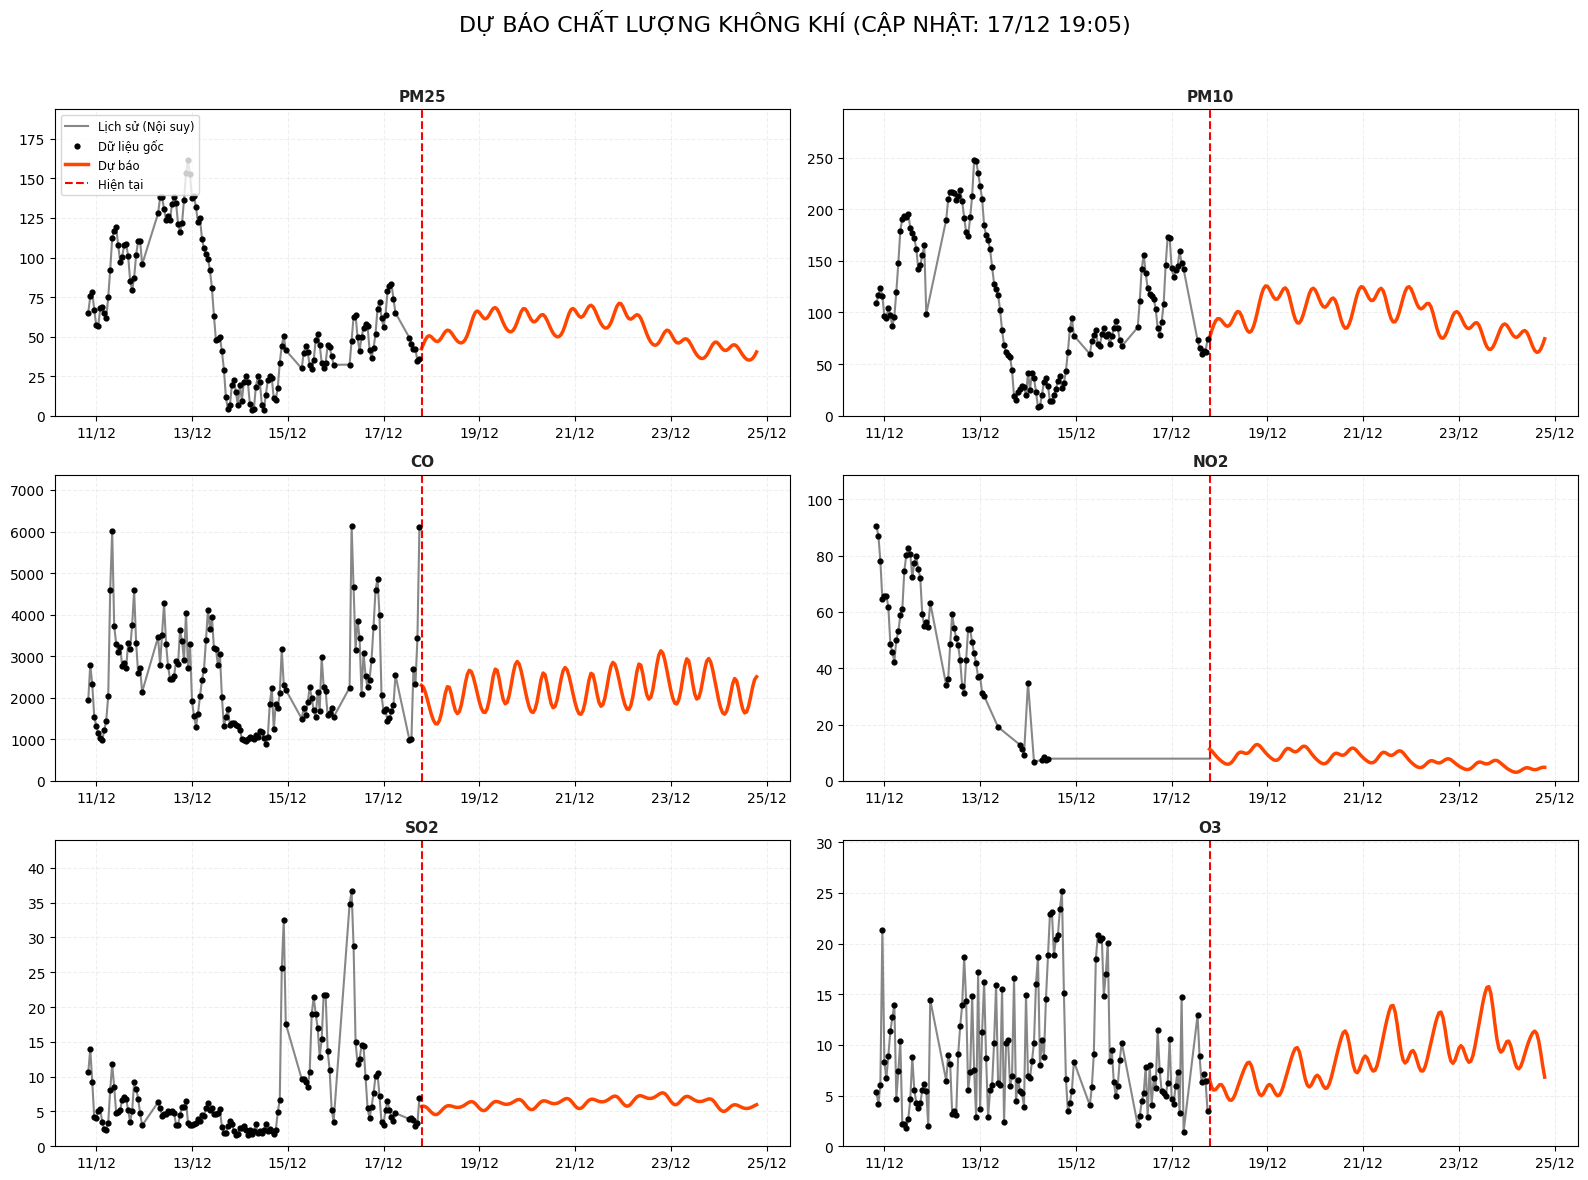

✅ Hoàn tất.


In [ ]:
def run_dashboard():
    gas_list = ['pm25', 'pm10', 'co', 'no2', 'so2', 'o3']

    print(f"🚀 Đang chạy dự báo (Giờ VN: {pd.Timestamp.now(tz=VN_TZ).strftime('%H:%M %d/%m')})...")
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    axes = axes.flatten()

    for i, gas in enumerate(gas_list):
        ax = axes[i]

        # 1. Lấy dữ liệu (Đã nội suy full đến hiện tại)
        df_history = get_data_for_gas(gas, days_history=90)

        if df_history is None:
            ax.text(0.5, 0.5, "Không có dữ liệu", ha='center')
            continue

        # 2. Dự báo tương lai
        df_forecast = generate_forecast(df_history, forecast_days=7)

        # 3. Vẽ
        plot_forecast_on_axis(ax, df_history, df_forecast, gas, zoom_days=7)

    plt.suptitle(f"DỰ BÁO CHẤT LƯỢNG KHÔNG KHÍ (CẬP NHẬT: {pd.Timestamp.now(tz=VN_TZ).strftime('%d/%m %H:%M')})", fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    print("✅ Hoàn tất.")

if __name__ == "__main__":
    run_dashboard()